# TiDE — Walmart Store Sales Forecasting

**Global Deep Learning model | Time-series Dense Encoder**


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import copy
import os
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import mlflow
import mlflow.pytorch

from sklearn.base import BaseEstimator, RegressorMixin

from mlflow_setup import init_mlflow
from features import (
    load_raw_data,
    merge_all,
    build_calendar_features,
    build_markdown_features,
    fill_macro_features,
    build_store_features,
)
from wmae import wmae

DATA_DIR     = "."
RANDOM_SEED  = 42
LOOKBACK     = 52
HORIZON      = 39
ORIGIN_STRIDE = 2

# Use None for the full assignment run.
# Set 300-500 only while debugging on CPU.
MAX_SERIES   = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")
print(f"MLflow version  : {mlflow.__version__}")
print("imports OK")


PyTorch version : 2.6.0+cu124
Device          : cuda
MLflow version  : 3.14.0
imports OK


---
## 1. TiDE Architecture

The model uses a feature projection for dynamic covariates, a dense residual encoder,
a dense decoder, and a horizon-wise temporal decoder.


In [2]:
class ResidualBlock(nn.Module):
    """Two-layer residual MLP block with LayerNorm."""

    def __init__(self, input_dim, hidden_dim, output_dim=None, dropout=0.1):
        super().__init__()
        output_dim = output_dim or input_dim

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.skip = (
            nn.Linear(input_dim, output_dim)
            if input_dim != output_dim
            else nn.Identity()
        )
        self.norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        hidden = F.gelu(self.fc1(x))
        hidden = self.dropout(self.fc2(hidden))
        return self.norm(hidden + self.skip(x))


class TiDE(nn.Module):
    """
    Compact TiDE-style model.

    y_past   : (batch, LOOKBACK)
    x_past   : (batch, LOOKBACK, n_dynamic)
    x_future : (batch, HORIZON, n_dynamic)
    output   : (batch, HORIZON)
    """

    def __init__(
        self,
        lookback,
        horizon,
        n_dynamic,
        n_static,
        n_stores,
        n_depts,
        store_embedding_dim=8,
        dept_embedding_dim=8,
        feature_projection_dim=8,
        hidden_dim=128,
        encoder_layers=2,
        decoder_layers=2,
        decoder_output_dim=32,
        dropout=0.15,
    ):
        super().__init__()

        self.lookback = lookback
        self.horizon = horizon
        self.decoder_output_dim = decoder_output_dim

        self.store_embedding = nn.Embedding(n_stores, store_embedding_dim)
        self.dept_embedding = nn.Embedding(n_depts, dept_embedding_dim)

        self.feature_projection = nn.Sequential(
            nn.Linear(n_dynamic, feature_projection_dim),
            nn.ReLU(),
        )

        static_dim = store_embedding_dim + dept_embedding_dim + n_static
        encoder_input_dim = (
            lookback
            + lookback * feature_projection_dim
            + horizon * feature_projection_dim
            + static_dim
        )

        encoder = [
            ResidualBlock(
                encoder_input_dim,
                hidden_dim,
                output_dim=hidden_dim,
                dropout=dropout,
            )
        ]
        for _ in range(encoder_layers - 1):
            encoder.append(
                ResidualBlock(hidden_dim, hidden_dim, dropout=dropout)
            )
        self.encoder = nn.Sequential(*encoder)

        decoder = []
        for _ in range(decoder_layers - 1):
            decoder.append(
                ResidualBlock(hidden_dim, hidden_dim, dropout=dropout)
            )
        decoder.append(
            ResidualBlock(
                hidden_dim,
                hidden_dim,
                output_dim=horizon * decoder_output_dim,
                dropout=dropout,
            )
        )
        self.decoder = nn.Sequential(*decoder)

        # Important: no LayerNorm on a one-dimensional scalar output.
        self.temporal_decoder = nn.Sequential(
            nn.Linear(decoder_output_dim + feature_projection_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, y_past, x_past, x_future, store_idx, dept_idx, static_num):
        batch_size = y_past.shape[0]

        projected_past = self.feature_projection(x_past)
        projected_future = self.feature_projection(x_future)

        static = torch.cat(
            [
                self.store_embedding(store_idx),
                self.dept_embedding(dept_idx),
                static_num,
            ],
            dim=-1,
        )

        encoder_input = torch.cat(
            [
                y_past,
                projected_past.reshape(batch_size, -1),
                projected_future.reshape(batch_size, -1),
                static,
            ],
            dim=-1,
        )

        encoded = self.encoder(encoder_input)
        decoded = self.decoder(encoded).view(
            batch_size, self.horizon, self.decoder_output_dim
        )

        temporal_input = torch.cat([decoded, projected_future], dim=-1)
        correction = self.temporal_decoder(temporal_input).squeeze(-1)

        # Strong weekly retail baseline:
        # future week h is initialized from the matching week 52 weeks earlier.
        seasonal_baseline = y_past[:, :self.horizon]

        return seasonal_baseline + correction


---
## 2. Data Loading and Feature Preparation


In [3]:
train_raw, test_raw, features_raw, stores_raw = load_raw_data(DATA_DIR)
train_merged, test_merged = merge_all(
    train_raw.copy(),
    test_raw.copy(),
    features_raw,
    stores_raw,
)

def build_tide_features(df):
    df = build_calendar_features(df)
    df = build_markdown_features(df)
    df = fill_macro_features(df)
    df = build_store_features(df)
    return df

train_feat = build_tide_features(train_merged)
test_feat = build_tide_features(test_merged)

train_feat["Date"] = pd.to_datetime(train_feat["Date"])
test_feat["Date"] = pd.to_datetime(test_feat["Date"])

train_feat = train_feat.sort_values(
    ["Store", "Dept", "Date"]
).reset_index(drop=True)

test_feat = test_feat.sort_values(
    ["Store", "Dept", "Date"]
).reset_index(drop=True)

print(f"train shape : {train_feat.shape}")
print(f"test shape  : {test_feat.shape}")
print(f"series      : {train_feat.groupby(['Store', 'Dept']).ngroups:,}")


train shape : (421570, 33)
test shape  : (115064, 32)
series      : 3,331


In [4]:
DYNAMIC_COVARIATES = [
    "Year", "Month", "WeekOfYear", "Quarter",
    "IsSuperBowl", "IsLaborDay", "IsThanksgiving", "IsChristmas",
    "WeeksBefore_SuperBowl", "WeeksBefore_Thanksgiving", "WeeksBefore_Christmas",
    "WeeksAfter_SuperBowl", "WeeksAfter_Thanksgiving", "WeeksAfter_Christmas",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "MarkDown_Total", "MarkDown_Count",
    "Temperature", "Fuel_Price", "CPI", "Unemployment",
    "IsHoliday",
]

STATIC_FEATURES = ["Size", "Type_Enc"]

stores_sorted = sorted(train_feat["Store"].unique())
depts_sorted = sorted(train_feat["Dept"].unique())

store2idx = {store: idx for idx, store in enumerate(stores_sorted)}
dept2idx = {dept: idx for idx, dept in enumerate(depts_sorted)}

all_dates = np.array(sorted(train_feat["Date"].unique()))
cutoff_date = pd.Timestamp(all_dates[-HORIZON])

df_train = train_feat[train_feat["Date"] < cutoff_date].reset_index(drop=True)
df_val = train_feat[train_feat["Date"] >= cutoff_date].reset_index(drop=True)

series_sizes = (
    df_train.groupby(["Store", "Dept"])
    .size()
    .sort_values(ascending=False)
)

if MAX_SERIES is not None:
    series_sizes = series_sizes.head(MAX_SERIES)

series_keys = list(series_sizes.index)

print(f"Cutoff date      : {cutoff_date.date()}")
print(f"Training rows    : {len(df_train):,}")
print(f"Validation rows  : {len(df_val):,}")
print(f"Selected series  : {len(series_keys):,}")


Cutoff date      : 2012-02-03
Training rows    : 305,982
Validation rows  : 115,588
Selected series  : 3,306


---
## 3. Leakage-Safe Scaling and Sliding Windows

The validation period is never used to fit target, dynamic-covariate, or static-feature
scalers. A training window is accepted only when its entire forecast horizon is before
the validation cutoff.


In [5]:
def fit_scalers(df):
    cov_mean = df[DYNAMIC_COVARIATES].mean()
    cov_std = df[DYNAMIC_COVARIATES].std().replace(0, 1.0).fillna(1.0)

    size_mean = float(df["Size"].mean())
    size_std = float(df["Size"].std())
    if not np.isfinite(size_std) or size_std < 1e-6:
        size_std = 1.0

    series_scalers = {}
    for key, group in df.groupby(["Store", "Dept"]):
        mean = float(group["Weekly_Sales"].mean())
        std = float(group["Weekly_Sales"].std())

        if not np.isfinite(std) or std < 1e-6:
            std = max(abs(mean) * 0.05, 1.0)

        series_scalers[key] = (mean, std)

    return {
        "cov_mean": cov_mean,
        "cov_std": cov_std,
        "size_mean": size_mean,
        "size_std": size_std,
        "series_scalers": series_scalers,
    }


def apply_scalers(df, scalers):
    result = df.copy()

    # Keep the unscaled holiday flag for the Kaggle-weighted loss.
    result["_IsHolidayRaw"] = result["IsHoliday"].astype(np.float32)

    result[DYNAMIC_COVARIATES] = (
        result[DYNAMIC_COVARIATES] - scalers["cov_mean"]
    ) / scalers["cov_std"]

    result["Size"] = (
        result["Size"] - scalers["size_mean"]
    ) / scalers["size_std"]

    return result


validation_scalers = fit_scalers(df_train)
train_scaled = apply_scalers(train_feat, validation_scalers)


In [6]:
def is_complete_weekly_window(dates):
    dates = pd.to_datetime(dates).values.astype("datetime64[D]")
    return np.all(np.diff(dates).astype("timedelta64[D]").astype(int) == 7)


def build_tide_windows(
    df,
    series_keys,
    scalers,
    mode="train",
    cutoff_date=None,
    stride=2,
):
    y_past_list = []
    x_past_list = []
    x_future_list = []
    y_future_list = []
    holiday_list = []
    store_idx_list = []
    dept_idx_list = []
    static_list = []
    target_mean_list = []
    target_std_list = []
    key_list = []

    for store, dept in series_keys:
        key = (store, dept)

        if key not in scalers["series_scalers"]:
            continue

        group = (
            df[(df["Store"] == store) & (df["Dept"] == dept)]
            .sort_values("Date")
            .reset_index(drop=True)
        )

        if len(group) < LOOKBACK + HORIZON:
            continue

        sales = group["Weekly_Sales"].values.astype(np.float32)
        covariates = group[DYNAMIC_COVARIATES].values.astype(np.float32)
        holidays = group["_IsHolidayRaw"].values.astype(np.float32)
        dates = group["Date"].values

        target_mean, target_std = scalers["series_scalers"][key]
        sales_scaled = (sales - target_mean) / target_std

        if mode == "validation":
            future_starts = np.where(
                dates >= np.datetime64(cutoff_date)
            )[0]

            if len(future_starts) == 0:
                continue

            future_starts = [int(future_starts[0])]
        else:
            future_starts = range(
                LOOKBACK,
                len(group) - HORIZON + 1,
                stride,
            )

        for future_start in future_starts:
            past_start = future_start - LOOKBACK
            future_end = future_start + HORIZON

            if past_start < 0 or future_end > len(group):
                continue

            if mode == "train":
                # The whole target horizon must finish before validation begins.
                if pd.Timestamp(dates[future_end - 1]) >= cutoff_date:
                    continue

            window_dates = dates[past_start:future_end]
            if not is_complete_weekly_window(window_dates):
                continue

            y_past_list.append(sales_scaled[past_start:future_start])
            x_past_list.append(covariates[past_start:future_start])
            x_future_list.append(covariates[future_start:future_end])
            y_future_list.append(sales_scaled[future_start:future_end])
            holiday_list.append(holidays[future_start:future_end])

            store_idx_list.append(store2idx[store])
            dept_idx_list.append(dept2idx[dept])
            static_list.append(
                [
                    float(group.loc[future_start - 1, "Size"]),
                    float(group.loc[future_start - 1, "Type_Enc"]),
                ]
            )

            target_mean_list.append(target_mean)
            target_std_list.append(target_std)
            key_list.append(key)

    if not y_past_list:
        raise ValueError("No valid TiDE windows were created.")

    return {
        "y_past": np.stack(y_past_list).astype(np.float32),
        "x_past": np.stack(x_past_list).astype(np.float32),
        "x_future": np.stack(x_future_list).astype(np.float32),
        "y_future": np.stack(y_future_list).astype(np.float32),
        "holiday": np.stack(holiday_list).astype(np.float32),
        "store_idx": np.asarray(store_idx_list, dtype=np.int64),
        "dept_idx": np.asarray(dept_idx_list, dtype=np.int64),
        "static": np.asarray(static_list, dtype=np.float32),
        "target_mean": np.asarray(target_mean_list, dtype=np.float32),
        "target_std": np.asarray(target_std_list, dtype=np.float32),
        "keys": key_list,
    }


train_windows = build_tide_windows(
    train_scaled,
    series_keys,
    validation_scalers,
    mode="train",
    cutoff_date=cutoff_date,
    stride=ORIGIN_STRIDE,
)

val_windows = build_tide_windows(
    train_scaled,
    series_keys,
    validation_scalers,
    mode="validation",
    cutoff_date=cutoff_date,
)

print(f"Training windows   : {len(train_windows['y_past']):,}")
print(f"Validation windows : {len(val_windows['y_past']):,}")
print(f"y_past shape       : {train_windows['y_past'].shape}")
print(f"x_future shape     : {train_windows['x_future'].shape}")


Training windows   : 18,802
Validation windows : 2,700
y_past shape       : (18802, 52)
x_future shape     : (18802, 39, 26)


In [7]:
class TiDEWindowDataset(Dataset):
    def __init__(self, windows):
        self.windows = windows

    def __len__(self):
        return len(self.windows["y_past"])

    def __getitem__(self, idx):
        return (
            torch.tensor(self.windows["y_past"][idx], dtype=torch.float32),
            torch.tensor(self.windows["x_past"][idx], dtype=torch.float32),
            torch.tensor(self.windows["x_future"][idx], dtype=torch.float32),
            torch.tensor(self.windows["y_future"][idx], dtype=torch.float32),
            torch.tensor(self.windows["holiday"][idx], dtype=torch.float32),
            torch.tensor(self.windows["store_idx"][idx], dtype=torch.long),
            torch.tensor(self.windows["dept_idx"][idx], dtype=torch.long),
            torch.tensor(self.windows["static"][idx], dtype=torch.float32),
            torch.tensor(self.windows["target_mean"][idx], dtype=torch.float32),
            torch.tensor(self.windows["target_std"][idx], dtype=torch.float32),
        )


train_dataset = TiDEWindowDataset(train_windows)
val_dataset = TiDEWindowDataset(val_windows)

print(f"Dataset sizes: train={len(train_dataset):,}, val={len(val_dataset):,}")


Dataset sizes: train=18,802, val=2,700


---
## 4. MLflow Initialisation


In [8]:
init_mlflow("TiDE_Training")
print("MLflow ready.")


Accessing as akave23

Initialized MLflow to track repo "sansi23/Walmart-Recruiting---Store-Sales-Forecasting"

Repository sansi23/Walmart-Recruiting---Store-Sales-Forecasting initialized!

DagsHub connected: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow


2026/07/11 22:49:43 INFO mlflow.tracking.fluent: Experiment with name 'TiDE_Training' does not exist. Creating a new experiment.


Experiment: TiDE_Training
Effective tracking URI: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow
MLflow ready.


---
## 5. Training and Evaluation Loop

The loss is holiday-weighted MAE. Errors from holiday weeks receive weight 5, matching
the Kaggle evaluation rule. Per-series target standard deviations convert normalized
errors back toward their original dollar scale.


In [9]:
def holiday_weighted_loss(prediction, target, holiday, target_std):
    weights = torch.where(
        holiday > 0.5,
        torch.tensor(5.0, device=holiday.device),
        torch.tensor(1.0, device=holiday.device),
    )

    dollar_error = torch.abs(prediction - target) * target_std.unsqueeze(1)

    # Dividing by a fixed value stabilizes gradients without changing the optimum.
    return torch.sum(weights * dollar_error) / torch.sum(weights) / 10000.0


def evaluate_tide(model, windows, batch_size=256):
    dataset = TiDEWindowDataset(windows)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    model.eval()

    all_true = []
    all_pred = []
    all_holiday = []

    with torch.no_grad():
        for batch in loader:
            (
                y_past,
                x_past,
                x_future,
                y_future,
                holiday,
                store_idx,
                dept_idx,
                static,
                target_mean,
                target_std,
            ) = batch

            y_past = y_past.to(DEVICE)
            x_past = x_past.to(DEVICE)
            x_future = x_future.to(DEVICE)
            store_idx = store_idx.to(DEVICE)
            dept_idx = dept_idx.to(DEVICE)
            static = static.to(DEVICE)

            pred_scaled = model(
                y_past,
                x_past,
                x_future,
                store_idx,
                dept_idx,
                static,
            ).cpu().numpy()

            mean_np = target_mean.numpy()[:, None]
            std_np = target_std.numpy()[:, None]

            pred_sales = pred_scaled * std_np + mean_np
            true_sales = y_future.numpy() * std_np + mean_np

            all_true.append(true_sales.reshape(-1))
            all_pred.append(pred_sales.reshape(-1))
            all_holiday.append(holiday.numpy().reshape(-1))

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    is_holiday = np.concatenate(all_holiday)

    return wmae(y_true, y_pred, is_holiday)


def train_tide(config, train_windows, val_windows, log_mlflow=True):
    train_dataset = TiDEWindowDataset(train_windows)
    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
        drop_last=False,
    )

    model = TiDE(
        lookback=LOOKBACK,
        horizon=HORIZON,
        n_dynamic=len(DYNAMIC_COVARIATES),
        n_static=len(STATIC_FEATURES),
        n_stores=len(store2idx),
        n_depts=len(dept2idx),
        store_embedding_dim=config.get("store_embedding_dim", 8),
        dept_embedding_dim=config.get("dept_embedding_dim", 8),
        feature_projection_dim=config["feature_projection_dim"],
        hidden_dim=config["hidden_dim"],
        encoder_layers=config["encoder_layers"],
        decoder_layers=config["decoder_layers"],
        decoder_output_dim=config["decoder_output_dim"],
        dropout=config["dropout"],
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config.get("weight_decay", 1e-4),
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config["epochs"],
    )

    best_state = copy.deepcopy(model.state_dict())
    best_wmae = float("inf")
    best_epoch = 0
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_wmae": [],
    }

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        epoch_loss = 0.0

        for batch in train_loader:
            (
                y_past,
                x_past,
                x_future,
                y_future,
                holiday,
                store_idx,
                dept_idx,
                static,
                target_mean,
                target_std,
            ) = batch

            y_past = y_past.to(DEVICE)
            x_past = x_past.to(DEVICE)
            x_future = x_future.to(DEVICE)
            y_future = y_future.to(DEVICE)
            holiday = holiday.to(DEVICE)
            store_idx = store_idx.to(DEVICE)
            dept_idx = dept_idx.to(DEVICE)
            static = static.to(DEVICE)
            target_std = target_std.to(DEVICE)

            optimizer.zero_grad()

            prediction = model(
                y_past,
                x_past,
                x_future,
                store_idx,
                dept_idx,
                static,
            )

            loss = holiday_weighted_loss(
                prediction,
                y_future,
                holiday,
                target_std,
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item() * len(y_past)

        scheduler.step()

        average_loss = epoch_loss / len(train_dataset)
        val_wmae = evaluate_tide(
            model,
            val_windows,
            batch_size=config["batch_size"],
        )

        history["train_loss"].append(average_loss)
        history["val_wmae"].append(val_wmae)

        if log_mlflow:
            mlflow.log_metric("train_loss", average_loss, step=epoch)
            mlflow.log_metric("val_wmae_epoch", val_wmae, step=epoch)
            mlflow.log_metric("lr", scheduler.get_last_lr()[0], step=epoch)

        if val_wmae < best_wmae:
            best_wmae = val_wmae
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"  Epoch {epoch:3d}/{config['epochs']}  "
                f"loss={average_loss:.4f}  val WMAE={val_wmae:,.2f}"
            )

        if patience_counter >= config.get("patience", 10):
            print(f"  Early stopping at epoch {epoch}.")
            break

    model.load_state_dict(best_state)

    if log_mlflow:
        mlflow.log_metric("val_wmae", best_wmae)
        mlflow.log_param("best_epoch", best_epoch)

    print(f"  Best validation WMAE: {best_wmae:,.2f}")
    return model, best_wmae, best_epoch, history


print("Training functions defined.")


Training functions defined.


---
## 6. Baseline TiDE

MLflow run: `TiDE_Baseline`


In [10]:
BASELINE_CONFIG = {
    "hidden_dim": 128,
    "encoder_layers": 2,
    "decoder_layers": 2,
    "feature_projection_dim": 8,
    "decoder_output_dim": 32,
    "store_embedding_dim": 8,
    "dept_embedding_dim": 8,
    "dropout": 0.15,
    "batch_size": 128,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 40,
    "patience": 8,
}

print("Training TiDE baseline...")

with mlflow.start_run(run_name="TiDE_Baseline") as run:
    mlflow.log_params(BASELINE_CONFIG)

    model_baseline, wmae_baseline, epoch_baseline, history_baseline = train_tide(
        BASELINE_CONFIG,
        train_windows,
        val_windows,
        log_mlflow=True,
    )

print(f"Baseline WMAE: {wmae_baseline:,.2f}")


Training TiDE baseline...
  Epoch   1/40  loss=0.1716  val WMAE=3,141.74
  Epoch   5/40  loss=0.1266  val WMAE=2,761.70
  Epoch  10/40  loss=0.1130  val WMAE=2,554.83
  Epoch  15/40  loss=0.1045  val WMAE=2,587.27
  Epoch  20/40  loss=0.0979  val WMAE=2,618.65
  Epoch  25/40  loss=0.0926  val WMAE=2,729.76
  Early stopping at epoch 26.
  Best validation WMAE: 2,498.57
🏃 View run TiDE_Baseline at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/8/runs/83d8e44c53ef4c4080a39ff63c22897b
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/8
Baseline WMAE: 2,498.57


---
## 7. Hyperparameter Comparison

MLflow runs: `TiDE_Tuning_*`

This is a small comparison of purposeful architectures rather than an expensive grid search.


In [11]:
SEARCH_CONFIGS = [
    {
        "name": "Compact",
        "hidden_dim": 96,
        "encoder_layers": 2,
        "decoder_layers": 1,
        "feature_projection_dim": 6,
        "decoder_output_dim": 24,
        "store_embedding_dim": 8,
        "dept_embedding_dim": 8,
        "dropout": 0.10,
        "batch_size": 128,
        "lr": 1.2e-3,
        "weight_decay": 1e-4,
        "epochs": 35,
        "patience": 7,
    },
    {
        "name": "Wide",
        "hidden_dim": 256,
        "encoder_layers": 3,
        "decoder_layers": 2,
        "feature_projection_dim": 12,
        "decoder_output_dim": 48,
        "store_embedding_dim": 12,
        "dept_embedding_dim": 12,
        "dropout": 0.20,
        "batch_size": 128,
        "lr": 6e-4,
        "weight_decay": 5e-4,
        "epochs": 45,
        "patience": 9,
    },
]

search_results = []

for config in SEARCH_CONFIGS:
    name = config["name"]
    print(f"\nTraining candidate: {name}")

    with mlflow.start_run(run_name=f"TiDE_Tuning_{name}") as run:
        mlflow.log_params(
            {key: value for key, value in config.items() if key != "name"}
        )

        model, score, best_epoch, history = train_tide(
            config,
            train_windows,
            val_windows,
            log_mlflow=True,
        )

    search_results.append(
        {
            "name": name,
            "config": config,
            "model": model,
            "wmae": score,
            "best_epoch": best_epoch,
            "history": history,
        }
    )

print("\nCandidate results:")
print(f"  {'Baseline':12s} WMAE = {wmae_baseline:,.2f}")

for result in search_results:
    print(f"  {result['name']:12s} WMAE = {result['wmae']:,.2f}")

comparison_names = ["Baseline"] + [result["name"] for result in search_results]
comparison_scores = [wmae_baseline] + [result["wmae"] for result in search_results]
comparison_colors = ["#6c757d", "#2a9d8f", "#457b9d"]

plt.figure(figsize=(8, 4.5))
bars = plt.bar(comparison_names, comparison_scores, color=comparison_colors)
plt.ylabel("Validation WMAE")
plt.title("TiDE configuration comparison")
plt.ylim(0, max(comparison_scores) * 1.18)
for bar, score in zip(bars, comparison_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 25, f"{score:,.2f}", ha="center")
plt.tight_layout()
plt.savefig("tide_model_comparison.png", dpi=120)
plt.show()



Training candidate: Compact
  Epoch   1/35  loss=0.1707  val WMAE=2,321.60
  Epoch   5/35  loss=0.1275  val WMAE=2,555.25
  Early stopping at epoch 8.
  Best validation WMAE: 2,321.60
🏃 View run TiDE_Tuning_Compact at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/8/runs/efbf8ccdfa3643769ecf15d752126020
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/8

Training candidate: Wide
  Epoch   1/45  loss=0.1741  val WMAE=2,527.46
  Epoch   5/45  loss=0.1259  val WMAE=2,537.06
  Epoch  10/45  loss=0.1090  val WMAE=2,729.04
  Early stopping at epoch 10.
  Best validation WMAE: 2,527.46
🏃 View run TiDE_Tuning_Wide at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/8/runs/e5d04f0b880c4ed3866729d32309f574
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/8

Candidate res

---
## 8. Select the Winner and Retrain on All Labeled Data

The honest model-selection score remains the held-out validation WMAE. After selection,
the winning architecture is retrained using all labeled weeks.


In [12]:
all_results = [
    {
        "name": "Baseline",
        "config": BASELINE_CONFIG,
        "model": model_baseline,
        "wmae": wmae_baseline,
        "best_epoch": epoch_baseline,
        "history": history_baseline,
    }
] + search_results

best = min(all_results, key=lambda result: result["wmae"])

print(f"Best model : {best['name']}")
print(f"Holdout WMAE: {best['wmae']:,.2f}")
print(f"Best epoch : {best['best_epoch']}")

best_config = best["config"].copy()
best_config["epochs"] = max(best["best_epoch"], 5)


Best model : Compact
Holdout WMAE: 2,321.60
Best epoch : 1


In [13]:
def train_tide_full(config, windows):
    dataset = TiDEWindowDataset(windows)
    loader = DataLoader(
        dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
        drop_last=False,
    )

    model = TiDE(
        lookback=LOOKBACK,
        horizon=HORIZON,
        n_dynamic=len(DYNAMIC_COVARIATES),
        n_static=len(STATIC_FEATURES),
        n_stores=len(store2idx),
        n_depts=len(dept2idx),
        store_embedding_dim=config.get("store_embedding_dim", 8),
        dept_embedding_dim=config.get("dept_embedding_dim", 8),
        feature_projection_dim=config["feature_projection_dim"],
        hidden_dim=config["hidden_dim"],
        encoder_layers=config["encoder_layers"],
        decoder_layers=config["decoder_layers"],
        decoder_output_dim=config["decoder_output_dim"],
        dropout=config["dropout"],
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config.get("weight_decay", 1e-4),
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config["epochs"],
    )

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        epoch_loss = 0.0

        for batch in loader:
            (
                y_past,
                x_past,
                x_future,
                y_future,
                holiday,
                store_idx,
                dept_idx,
                static,
                target_mean,
                target_std,
            ) = batch

            y_past = y_past.to(DEVICE)
            x_past = x_past.to(DEVICE)
            x_future = x_future.to(DEVICE)
            y_future = y_future.to(DEVICE)
            holiday = holiday.to(DEVICE)
            store_idx = store_idx.to(DEVICE)
            dept_idx = dept_idx.to(DEVICE)
            static = static.to(DEVICE)
            target_std = target_std.to(DEVICE)

            optimizer.zero_grad()

            prediction = model(
                y_past,
                x_past,
                x_future,
                store_idx,
                dept_idx,
                static,
            )

            loss = holiday_weighted_loss(
                prediction,
                y_future,
                holiday,
                target_std,
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item() * len(y_past)

        scheduler.step()

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"  Epoch {epoch:3d}/{config['epochs']}  "
                f"loss={epoch_loss / len(dataset):.4f}"
            )

    return model


In [14]:
final_scalers = fit_scalers(train_feat)
final_scaled = apply_scalers(train_feat, final_scalers)

final_series_sizes = (
    train_feat.groupby(["Store", "Dept"])
    .size()
    .sort_values(ascending=False)
)

if MAX_SERIES is not None:
    final_series_sizes = final_series_sizes.head(MAX_SERIES)

final_series_keys = list(final_series_sizes.index)

# A date after the final label lets build_tide_windows use every possible origin.
after_last_train_date = train_feat["Date"].max() + pd.Timedelta(days=7)

final_windows = build_tide_windows(
    final_scaled,
    final_series_keys,
    final_scalers,
    mode="train",
    cutoff_date=after_last_train_date,
    stride=ORIGIN_STRIDE,
)

print(f"Final training windows: {len(final_windows['y_past']):,}")
print(f"Training final {best['name']} model...")

with mlflow.start_run(run_name="TiDE_Final") as run:
    mlflow.log_params(
        {key: value for key, value in best_config.items() if key != "name"}
    )
    mlflow.log_param("best_variant", best["name"])
    mlflow.log_metric("held_out_val_wmae", best["wmae"])

    final_model = train_tide_full(best_config, final_windows)

    torch.save(final_model.state_dict(), "tide_final.pt")
    mlflow.log_artifact("tide_final.pt")

    mlflow.pytorch.log_model(
        pytorch_model=final_model,
        artifact_path="tide_model",
        registered_model_name="TiDE_WalmartSales",
        serialization_format="pickle",
    )

    final_run_id = run.info.run_id

print(f"Final run id  : {final_run_id}")
print(f"Holdout WMAE  : {best['wmae']:,.2f}")
print("Registered as : TiDE_WalmartSales")


Final training windows: 72,600
Training final Compact model...
  Epoch   1/5  loss=0.1689
  Epoch   5/5  loss=0.1301


2026/07/11 22:55:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 22:55:32 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/11 22:55:32 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/11 22:55:44 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+

🏃 View run TiDE_Final at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/8/runs/33d604cdf4b0464fb29125c457b2846b
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/8
Final run id  : 33d604cdf4b0464fb29125c457b2846b
Holdout WMAE  : 2,321.60
Registered as : TiDE_WalmartSales


---
## 9. Inference Pipeline and Kaggle Submission

The wrapper accepts the raw Walmart `test.csv`, merges the auxiliary tables, builds the
same features, and predicts each Store–Department horizon in its original row order.


In [15]:
def build_lookback_state(train_df, scaled_df, series_keys, scalers):
    state = {}

    for key in series_keys:
        store, dept = key

        raw_group = (
            train_df[
                (train_df["Store"] == store)
                & (train_df["Dept"] == dept)
            ]
            .sort_values("Date")
            .tail(LOOKBACK)
        )

        scaled_group = (
            scaled_df[
                (scaled_df["Store"] == store)
                & (scaled_df["Dept"] == dept)
            ]
            .sort_values("Date")
            .tail(LOOKBACK)
        )

        if len(raw_group) < LOOKBACK or len(scaled_group) < LOOKBACK:
            continue

        if not is_complete_weekly_window(raw_group["Date"].values):
            continue

        mean, std = scalers["series_scalers"][key]

        state[key] = {
            "y_past": (
                (raw_group["Weekly_Sales"].values.astype(np.float32) - mean) / std
            ),
            "x_past": scaled_group[DYNAMIC_COVARIATES].values.astype(np.float32),
        }

    return state


lookback_state = build_lookback_state(
    train_feat,
    final_scaled,
    final_series_keys,
    final_scalers,
)

series_medians = (
    train_feat.groupby(["Store", "Dept"])["Weekly_Sales"]
    .median()
    .to_dict()
)

global_median = float(train_feat["Weekly_Sales"].median())

print(f"Series with lookback state: {len(lookback_state):,}")


Series with lookback state: 2,755


In [16]:
class TiDEPipeline(BaseEstimator, RegressorMixin):
    """Sklearn-compatible inference wrapper for raw Walmart test rows."""

    def __init__(
        self,
        model,
        features_df,
        stores_df,
        lookback_state,
        scalers,
        store2idx,
        dept2idx,
        series_medians,
        global_median,
        device=DEVICE,
    ):
        self.model = model
        self.features_df = features_df
        self.stores_df = stores_df
        self.lookback_state = lookback_state
        self.scalers = scalers
        self.store2idx = store2idx
        self.dept2idx = dept2idx
        self.series_medians = series_medians
        self.global_median = global_median
        self.device = device

    def fit(self, X, y=None):
        return self

    def _prepare_features(self, X):
        df = X.copy()
        df["_row_order"] = np.arange(len(df))

        if not np.issubdtype(df["Date"].dtype, np.datetime64):
            df["Date"] = pd.to_datetime(df["Date"])

        feature_table = self.features_df.copy()
        feature_table["Date"] = pd.to_datetime(feature_table["Date"])

        # Avoid a duplicate IsHoliday column from features.csv.
        feature_table = feature_table.drop(
            columns=["IsHoliday"],
            errors="ignore",
        )

        df = df.merge(
            feature_table,
            on=["Store", "Date"],
            how="left",
        )

        df = df.merge(
            self.stores_df,
            on="Store",
            how="left",
        )

        df = build_calendar_features(df)
        df = build_markdown_features(df)
        df = fill_macro_features(df)
        df = build_store_features(df)

        return df

    def predict(self, X):
        df = self._prepare_features(X)
        scaled = apply_scalers(df, self.scalers)

        predictions = np.full(
            len(df),
            self.global_median,
            dtype=np.float32,
        )

        self.model = self.model.to(self.device)
        self.model.eval()

        for (store, dept), group in scaled.groupby(["Store", "Dept"]):
            key = (store, dept)
            original_group = df.loc[group.index]

            fallback = self.series_medians.get(key, self.global_median)
            predictions[original_group["_row_order"].values] = fallback

            if (
                key not in self.lookback_state
                or key not in self.scalers["series_scalers"]
                or store not in self.store2idx
                or dept not in self.dept2idx
            ):
                continue

            group = group.sort_values("Date")
            original_group = df.loc[group.index].sort_values("Date")

            if len(group) == 0:
                continue

            future_covariates = group[
                DYNAMIC_COVARIATES
            ].values.astype(np.float32)

            if len(future_covariates) < HORIZON:
                padding = np.repeat(
                    future_covariates[-1:],
                    HORIZON - len(future_covariates),
                    axis=0,
                )
                future_covariates = np.concatenate(
                    [future_covariates, padding],
                    axis=0,
                )
            else:
                future_covariates = future_covariates[:HORIZON]

            history = self.lookback_state[key]

            y_past = torch.tensor(
                history["y_past"],
                dtype=torch.float32,
            ).unsqueeze(0).to(self.device)

            x_past = torch.tensor(
                history["x_past"],
                dtype=torch.float32,
            ).unsqueeze(0).to(self.device)

            x_future = torch.tensor(
                future_covariates,
                dtype=torch.float32,
            ).unsqueeze(0).to(self.device)

            store_idx = torch.tensor(
                [self.store2idx[store]],
                dtype=torch.long,
                device=self.device,
            )

            dept_idx = torch.tensor(
                [self.dept2idx[dept]],
                dtype=torch.long,
                device=self.device,
            )

            static = torch.tensor(
                [[
                    float(group.iloc[0]["Size"]),
                    float(group.iloc[0]["Type_Enc"]),
                ]],
                dtype=torch.float32,
                device=self.device,
            )

            with torch.no_grad():
                forecast_scaled = self.model(
                    y_past,
                    x_past,
                    x_future,
                    store_idx,
                    dept_idx,
                    static,
                ).squeeze(0).cpu().numpy()

            mean, std = self.scalers["series_scalers"][key]
            forecast = forecast_scaled * std + mean

            row_orders = original_group["_row_order"].values
            n_predictions = min(len(row_orders), HORIZON)

            predictions[row_orders[:n_predictions]] = forecast[:n_predictions]

        return predictions


In [17]:
tide_pipeline = TiDEPipeline(
    model=final_model,
    features_df=features_raw,
    stores_df=stores_raw,
    lookback_state=lookback_state,
    scalers=final_scalers,
    store2idx=store2idx,
    dept2idx=dept2idx,
    series_medians=series_medians,
    global_median=global_median,
)

with open("tide_pipeline.pkl", "wb") as file:
    pickle.dump(tide_pipeline, file)

with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact("tide_pipeline.pkl")

test_predictions = tide_pipeline.predict(test_raw)

submission = pd.DataFrame(
    {
        "Id": (
            test_raw["Store"].astype(str)
            + "_"
            + test_raw["Dept"].astype(str)
            + "_"
            + pd.to_datetime(test_raw["Date"]).dt.strftime("%Y-%m-%d")
        ),
        "Weekly_Sales": test_predictions,
    }
)

submission.to_csv("submission_tide.csv", index=False)

print(submission.head())
print(f"Saved submission_tide.csv with {len(submission):,} rows.")
print("TiDEPipeline saved to tide_pipeline.pkl")


🏃 View run TiDE_Final at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/8/runs/33d604cdf4b0464fb29125c457b2846b
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/8
               Id  Weekly_Sales
0  1_1_2012-11-02  35320.273438
1  1_1_2012-11-09  23976.556641
2  1_1_2012-11-16  24685.167969
3  1_1_2012-11-23  22158.330078
4  1_1_2012-11-30  24220.369141
Saved submission_tide.csv with 115,064 rows.
TiDEPipeline saved to tide_pipeline.pkl


---
## 10. Forecast Visualisation


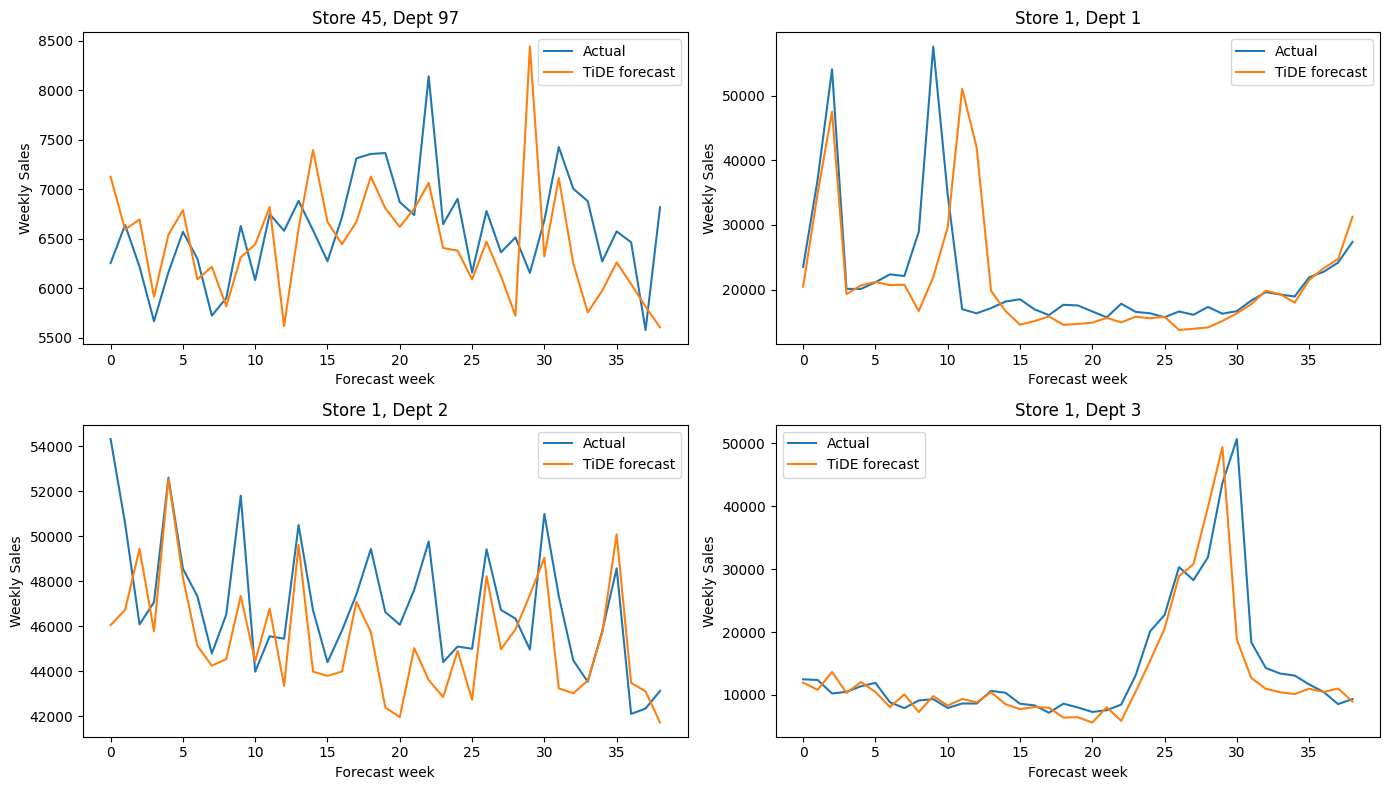

In [18]:
validation_model = best["model"].to(DEVICE)
validation_model.eval()

n_plots = min(4, len(val_windows["y_past"]))
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = np.asarray(axes).reshape(-1)

for sample_idx in range(n_plots):
    y_past = torch.tensor(
        val_windows["y_past"][sample_idx],
        dtype=torch.float32,
    ).unsqueeze(0).to(DEVICE)

    x_past = torch.tensor(
        val_windows["x_past"][sample_idx],
        dtype=torch.float32,
    ).unsqueeze(0).to(DEVICE)

    x_future = torch.tensor(
        val_windows["x_future"][sample_idx],
        dtype=torch.float32,
    ).unsqueeze(0).to(DEVICE)

    store_idx = torch.tensor(
        [val_windows["store_idx"][sample_idx]],
        dtype=torch.long,
        device=DEVICE,
    )

    dept_idx = torch.tensor(
        [val_windows["dept_idx"][sample_idx]],
        dtype=torch.long,
        device=DEVICE,
    )

    static = torch.tensor(
        val_windows["static"][sample_idx],
        dtype=torch.float32,
    ).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_scaled = validation_model(
            y_past,
            x_past,
            x_future,
            store_idx,
            dept_idx,
            static,
        ).squeeze(0).cpu().numpy()

    mean = val_windows["target_mean"][sample_idx]
    std = val_windows["target_std"][sample_idx]

    prediction = pred_scaled * std + mean
    actual = val_windows["y_future"][sample_idx] * std + mean

    store, dept = val_windows["keys"][sample_idx]

    axes[sample_idx].plot(actual, label="Actual")
    axes[sample_idx].plot(prediction, label="TiDE forecast")
    axes[sample_idx].set_title(f"Store {store}, Dept {dept}")
    axes[sample_idx].set_xlabel("Forecast week")
    axes[sample_idx].set_ylabel("Weekly Sales")
    axes[sample_idx].legend()

for axis in axes[n_plots:]:
    axis.axis("off")

plt.tight_layout()
plt.savefig("tide_forecasts.png", dpi=120)
plt.show()
